In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
train = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/train.csv')

# **1. EDA**

In [4]:
train.shape

(4459, 4993)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Columns: 4993 entries, ID to 9fc776466
dtypes: float64(1845), int64(3147), object(1)
memory usage: 169.9+ MB


In [6]:
train.head()

,ID,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,000d6aaf2,38000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,000fbd867,600000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0027d6b71,10000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0028cbf45,2000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,002a68644,14400000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [7]:
train.describe().round(2)

,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
count,4459.00,4459.00,4459.00,4459.00,4459.00,4.459000e+03,4459.00,4459.00,4459.00,4.459000e+03,...,4459.00,4.459000e+03,4.459000e+03,4.459000e+03,4459.00,4.459000e+03,4.459000e+03,4.459000e+03,4459.00,4459.00
mean,5944923.32,14654.93,1390.89,26722.45,4530.16,2.640996e+04,30708.11,16865.22,4669.21,2.569407e+06,...,467605.70,4.446239e+05,8.056219e+05,7.812966e+05,143.53,1.213809e+05,3.573451e+04,3.123741e+05,92199.60,227909.96
std,8234311.50,389329.81,64283.02,569965.18,235912.41,1.514730e+06,577058.97,751275.59,187944.89,9.610183e+06,...,4068037.55,4.428889e+06,4.513246e+06,6.839451e+06,9584.32,4.720709e+06,1.614622e+06,4.318501e+06,1635993.43,1811139.28
min,30000.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,...,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00
25%,600000.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,...,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00
50%,2260000.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.000000e+00,...,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00
75%,8000000.00,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,6.000000e+05,...,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.00
max,40000000.00,20000000.00,4000000.00,20000000.00,14800000.00,1.000000e+08,20708000.00,40000000.00,10400000.00,3.196120e+08,...,76000000.00,1.235880e+08,1.300000e+08,1.444000e+08,640000.00,3.013120e+08,1.064200e+08,1.400000e+08,61768000.00,43200000.00


In [8]:
train.isnull().sum()

ID           0
target       0
48df886f9    0
0deb4b6a8    0
34b15f335    0
            ..
71b203550    0
137efaa80    0
fb36b89d9    0
7e293fbaf    0
9fc776466    0
Length: 4993, dtype: int64

Проверяю признаки с большим количеством нулей

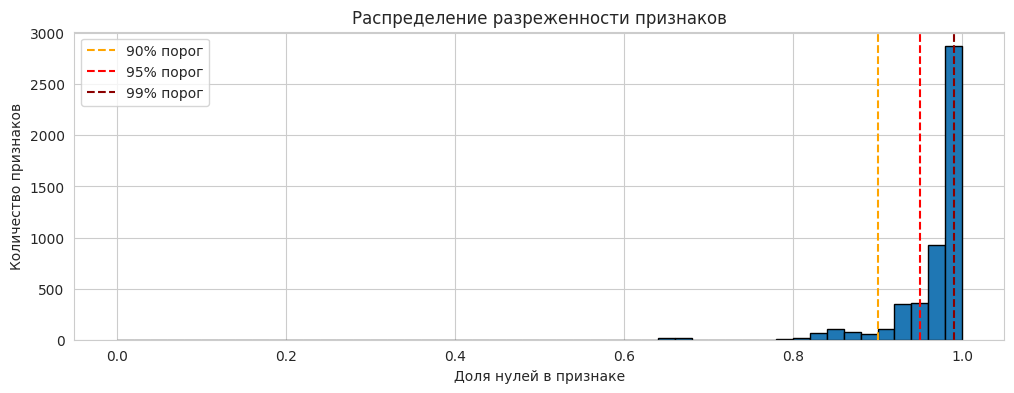

Признаков с >90% нулей: 4615
Признаков с >95% нулей: 3994
Признаков с >99% нулей: 2364
Признаков с 100% нулей: 256


In [9]:
zero_ratio = (train == 0).mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
plt.hist(zero_ratio, bins=50, edgecolor='black')
plt.axvline(0.90, color='orange', linestyle='--', label='90% порог')
plt.axvline(0.95, color='red', linestyle='--', label='95% порог')
plt.axvline(0.99, color='darkred', linestyle='--', label='99% порог')
plt.xlabel('Доля нулей в признаке')
plt.ylabel('Количество признаков')
plt.legend()
plt.title('Распределение разреженности признаков')
plt.show()

print(f"Признаков с >90% нулей: {(zero_ratio > 0.9).sum()}")
print(f"Признаков с >95% нулей: {(zero_ratio > 0.95).sum()}")
print(f"Признаков с >99% нулей: {(zero_ratio > 0.99).sum()}")
print(f"Признаков с 100% нулей: {(zero_ratio == 1).sum()}")

256 признаков имеют только одно значение: 0, их можно спокойно удалять. А также удалим признак id

In [10]:
cols_100_zero = zero_ratio[zero_ratio == 1].index
train = train.drop(cols_100_zero, axis=1)
train = train.drop('ID', axis=1)
test = pd.read_csv('/kaggle/input/competitions/santander-value-prediction-challenge/test.csv')
test_ID = test['ID']
test = test.drop('ID', axis = 1)
test = test.drop(cols_100_zero, axis=1)

Почти 50% данных имеют >99% нулей. Проверим есть ли полезные признаки среди них

In [11]:
X_train = train.drop('target', axis=1)
y_train = train['target']

zero_ratio = (X_train == 0).mean().sort_values(ascending=False)

high_zero_cols = zero_ratio[zero_ratio > 0.99].index
print(f"Признаков с >99% нулей: {len(high_zero_cols)}")

corr_with_target = X_train[high_zero_cols].corrwith(y_train).sort_values(ascending=False)

print("\nТоп-10 корреляций среди >99% нулей:")
print(corr_with_target.head(10))

useful_high_zero = corr_with_target[abs(corr_with_target) > 0.02]
print(f"\nПолезных признаков среди >99% нулей (|corr| > 0.02): {len(useful_high_zero)}")

if len(useful_high_zero) > 0:
    print("\nСписок полезных признаков:")
    print(useful_high_zero)
else:
    print("\nНет полезных признаков с корреляцией > 0.02")

Признаков с >99% нулей: 2108

Топ-10 корреляций среди >99% нулей:
0ccd6454a    0.082864
8984e4066    0.082062
7194699cd    0.080461
b66bf9d44    0.079596
1c4157dfd    0.079198
a636266f3    0.077972
bbd16b7a0    0.074726
d80abf8bc    0.073123
de7063efa    0.072024
15b0fe826    0.067363
dtype: float64

Полезных признаков среди >99% нулей (|corr| > 0.02): 383

Список полезных признаков:
0ccd6454a    0.082864
8984e4066    0.082062
7194699cd    0.080461
b66bf9d44    0.079596
1c4157dfd    0.079198
               ...   
371ff7a11   -0.041135
cb162bd89   -0.041329
052f67cfa   -0.043458
36d35623e   -0.045601
3c27b0b28   -0.047145
Length: 383, dtype: float64


Довольно значимая, часть признаков с количеством нулей более 99% показала корреляцию >0.02, это значит, что их нельзя так просто проигнорировать

Посмотрим корреляцию всех признаков с целевой переменной.

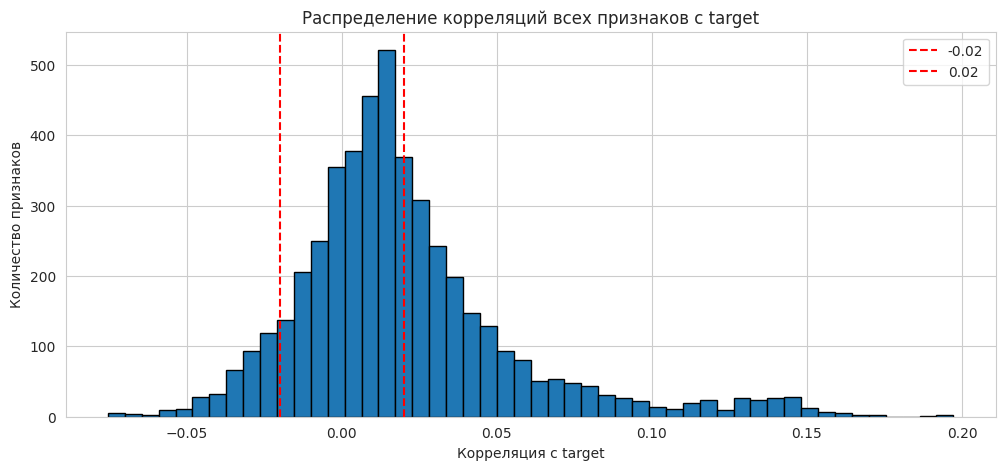


Признаков с |corr| < 0.02: 1725
Топ-20 положительных корреляций:
9fd594eec    0.197227
f190486d6    0.195313
6eef030c1    0.194630
58e2e02e6    0.187259
70feb1494    0.173549
f74e8f13d    0.172804
26fc93eb7    0.172285
1702b5bf0    0.168431
fb49e4212    0.167091
58232a6fb    0.163608
fc99f9426    0.161864
1c71183bb    0.160103
20aa07010    0.159419
324921c7b    0.159375
ba4ceabc5    0.158138
963a49cdc    0.157060
b43a7cfd5    0.157013
f3cf9341c    0.155248
491b9ee45    0.154638
e1d0e11b5    0.153776
dtype: float64

Топ-20 отрицательных корреляций:
e9c7ccc05   -0.053742
e2b4d4ef7   -0.054325
dc6676b1f   -0.054384
0bb96a2ae   -0.054602
0a7c079ff   -0.056509
54428f346   -0.058168
3c27b0b28   -0.058607
072452760   -0.058803
e0a18e5b6   -0.058875
d8e8397ce   -0.060123
6d773e96f   -0.060870
dc135562a   -0.064656
98af380ad   -0.065636
d01cc5805   -0.066722
2087ed398   -0.069043
f41af7c85   -0.069983
79c8119ae   -0.070613
cb162bd89   -0.071221
b4cd81ecd   -0.071332
371ff7a11   -0.075334
dtype

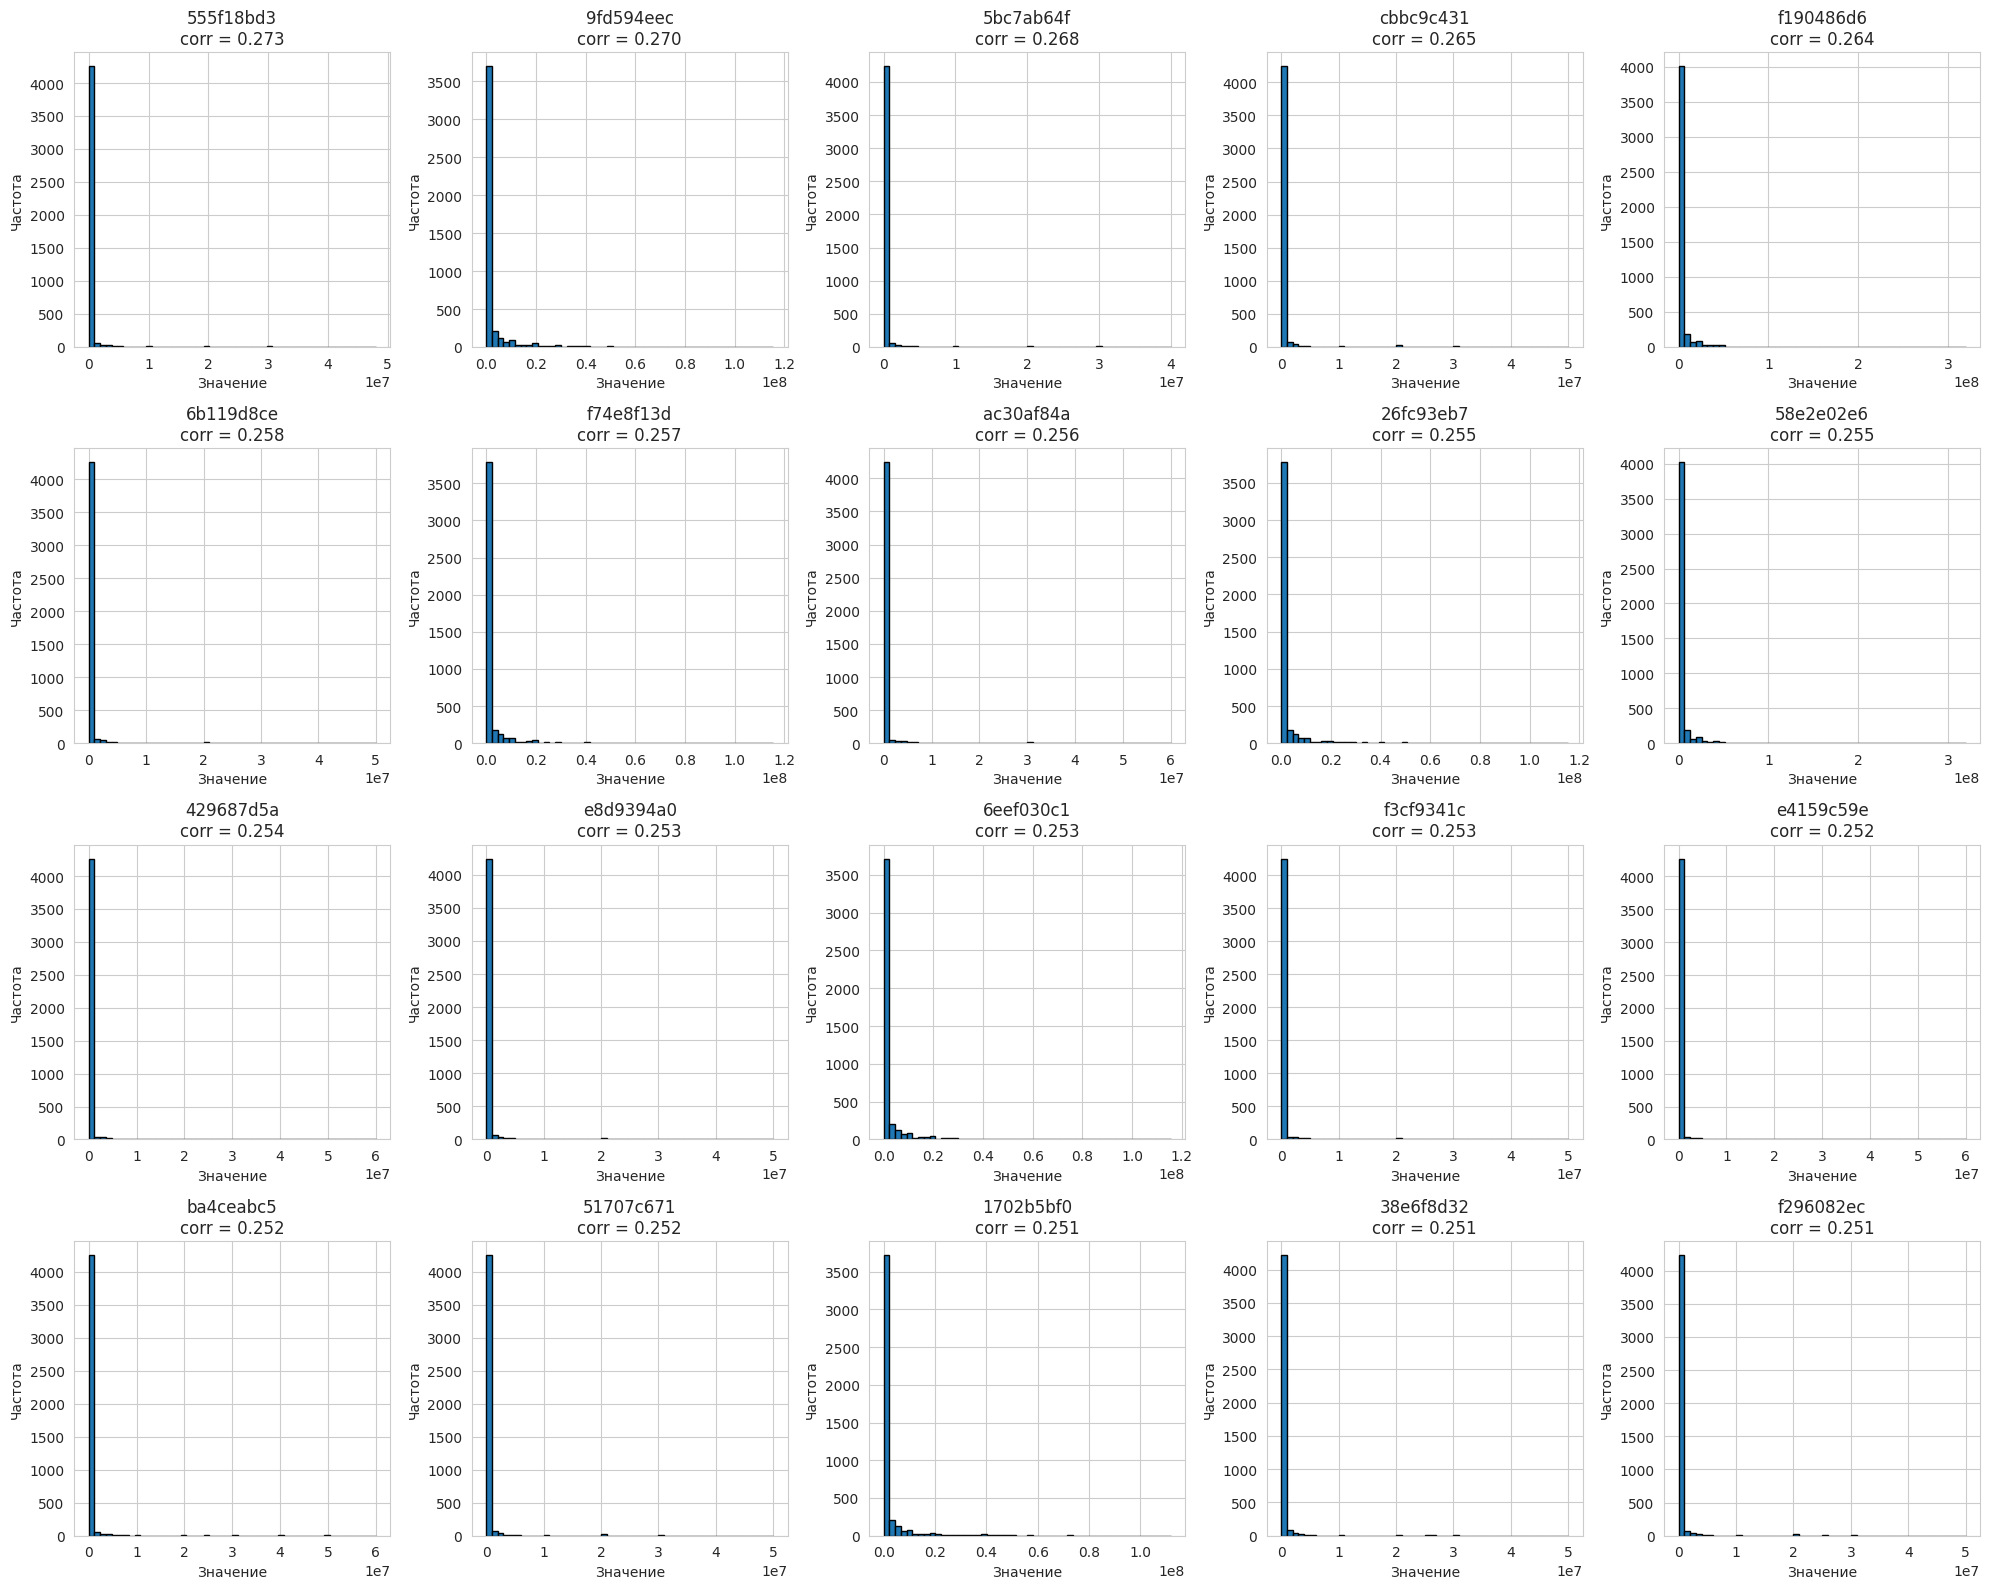

In [12]:
y_train_log = np.log1p(y_train)
all_correlations = X_train.corrwith(y_train_log).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.hist(all_correlations, bins=50, edgecolor='black')
plt.axvline(-0.02, color='red', linestyle='--', label='-0.02')
plt.axvline(0.02, color='red', linestyle='--', label='0.02')
plt.xlabel('Корреляция с target')
plt.ylabel('Количество признаков')
plt.legend()
plt.title('Распределение корреляций всех признаков с target')
plt.show()

corr_with_target_all = X_train.corrwith(y_train)
low_corr = corr_with_target[abs(corr_with_target_all) < 0.02]
print(f"\nПризнаков с |corr| < 0.02: {len(low_corr)}")

print("Топ-20 положительных корреляций:")
print(all_correlations.head(20))
print("\nТоп-20 отрицательных корреляций:")
print(all_correlations.tail(20))

top_features = abs(X_train.corrwith(y_train)).sort_values(ascending=False).head(20).index

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    X_train[feature].hist(bins=50, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{feature}\ncorr = {X_train[feature].corr(y_train):.3f}')
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Большое число признаков имеют корреляцию с целевой переменной ниже 0.02, значения отрицательных корреляций довольно низкие

У признаков высокоскорелированных между собой долны быть близкие значения корреляции с target, поскольку суть заключается в том, что они влияют на неё одинаково. Ищем признаки-дубликаты, возьмём логариф

Анализ топ-500 признаков на дубликаты
Найдено 1 уникальных пар с корреляцией > 0.95:

  cef9ab060  - corr с target: 0.0734
  46c525541 - corr с target: 0.0694
Корреляция между cef9ab060  и 46c525541 : 0.9556
Статистика по топ-500 признакам:
Диапазон корреляций: 0.0603 - 0.1972
Средняя корреляция: 0.1006


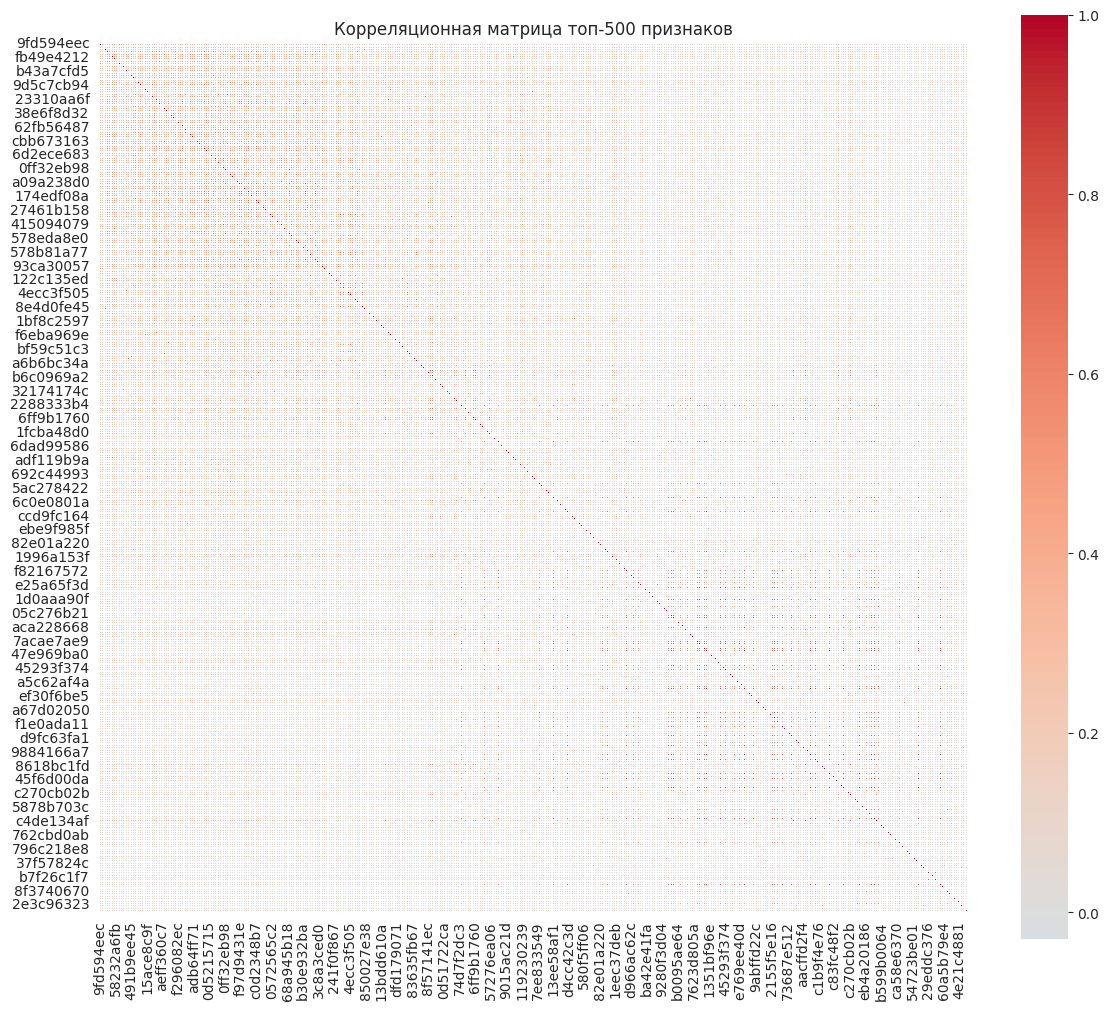

In [13]:
corr_with_target = X_train.corrwith(y_train_log).sort_values(ascending=False)

top_n = 500
top_features = corr_with_target.head(top_n).index.tolist()

print(f"Анализ топ-{top_n} признаков на дубликаты")

duplicate_pairs = []
checked_pairs = set()  

for i, feat1 in enumerate(top_features):
    corr1 = corr_with_target[feat1]
    
    similar_features = []
    for feat2 in top_features[i+1:]:
        corr2 = corr_with_target[feat2]
        if abs(corr1 - corr2) < 0.02:
            similar_features.append(feat2)
    
    if similar_features:
        features_to_check = [feat1] + similar_features
        corr_matrix = X_train[features_to_check].corr()
        
        for i2 in range(len(features_to_check)):
            for j2 in range(i2+1, len(features_to_check)):
                f1 = features_to_check[i2]
                f2 = features_to_check[j2]
                
                pair = tuple(sorted([f1, f2]))
                
                if pair not in checked_pairs:
                    checked_pairs.add(pair)
                    
                    corr_between = corr_matrix.iloc[i2, j2]
                    if abs(corr_between) > 0.95:
                        duplicate_pairs.append({
                            'feature1': f1,
                            'feature2': f2,
                            'corr_with_target1': corr_with_target[f1],
                            'corr_with_target2': corr_with_target[f2],
                            'corr_between': corr_between
                        })

if duplicate_pairs:
    print(f"Найдено {len(duplicate_pairs)} уникальных пар с корреляцией > 0.95:")
    
    duplicate_pairs_sorted = sorted(duplicate_pairs, 
                                   key=lambda x: abs(x['corr_between']), 
                                   reverse=True)
    
    for pair in duplicate_pairs_sorted:
        print(f"\n  {pair['feature1']}  - corr с target: {pair['corr_with_target1']:.4f}")
        print(f"  {pair['feature2']} - corr с target: {pair['corr_with_target2']:.4f}")
        print(f"Корреляция между {pair['feature1']}  и {pair['feature2']} : {pair['corr_between']:.4f}")
else:
    print("Нет пар с корреляцией > 0.95)")

print("Статистика по топ-500 признакам:")
print(f"Диапазон корреляций: {corr_with_target[top_features].min():.4f} - {corr_with_target[top_features].max():.4f}")
print(f"Средняя корреляция: {corr_with_target[top_features].mean():.4f}")

plt.figure(figsize=(14, 12))
corr_matrix_top500 = X_train[top_features].corr()
sns.heatmap(corr_matrix_top500, cmap='coolwarm', center=0, 
            annot=False, square=True, linewidths=0.5)
plt.title(f'Корреляционная матрица топ-{top_n} признаков')
plt.show()

Среди топ-500 признаков по скоррелированности с target нашлась всего 1 пара признаков-дубликатов

Удалим один из признаков-дубликатов

In [14]:
test = test.drop('46c525541', axis = 1)
X_train = X_train.drop('46c525541', axis = 1)
train = train.drop('46c525541', axis = 1)

In [15]:
total_missing_train = train.isnull().sum().sum()
print(f"Всего пропусков в train: {total_missing_train}")

missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

if len(missing_train) > 0:
    print(f"\nКолонок с пропусками: {len(missing_train)}")
    print(f"\nТоп-10 колонок с пропусками:")
    print(missing_train.head(10))
    
    missing_percent = (missing_train / len(train)) * 100
    print(f"\nПроцент пропусков в топ-10:")
    print(missing_percent.head(10).round(2))
    
    print("\nРаспределение пропусков по колонкам:")
    print(f"Колонок с < 5% пропусков: {(missing_percent < 5).sum()}")
    print(f"Колонок с 5-20% пропусков: {((missing_percent >= 5) & (missing_percent < 20)).sum()}")
    print(f"Колонок с 20-50% пропусков: {((missing_percent >= 20) & (missing_percent < 50)).sum()}")
    print(f"Колонок с > 50% пропусков: {(missing_percent >= 50).sum()}")
    
    plt.figure(figsize=(12, 6))
    missing_percent_sorted = missing_percent.sort_values(ascending=False)
    plt.bar(range(len(missing_percent_sorted)), missing_percent_sorted.values)
    plt.axhline(y=5, color='green', linestyle='--', label='5% порог')
    plt.axhline(y=20, color='orange', linestyle='--', label='20% порог')
    plt.axhline(y=50, color='red', linestyle='--', label='50% порог')
    plt.xlabel('Колонки с пропусками')
    plt.ylabel('Процент пропусков')
    plt.title('Распределение пропусков по колонкам')
    plt.legend()
    plt.show()

total_missing_test = test.isnull().sum().sum()
print(f"Всего пропусков в test: {total_missing_test}")

missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

if len(missing_test) > 0:
    print(f"\nКолонок с пропусками в test: {len(missing_test)}")
    print(f"Топ-10 колонок с пропусками в test:")
    print(missing_test.head(10))
    
    missing_percent_test = (missing_test / len(test)) * 100
    print(f"\nПроцент пропусков в test (топ-10):")
    print(missing_percent_test.head(10).round(2))

Всего пропусков в train: 0
Всего пропусков в test: 0


Исследуем выбросы в target

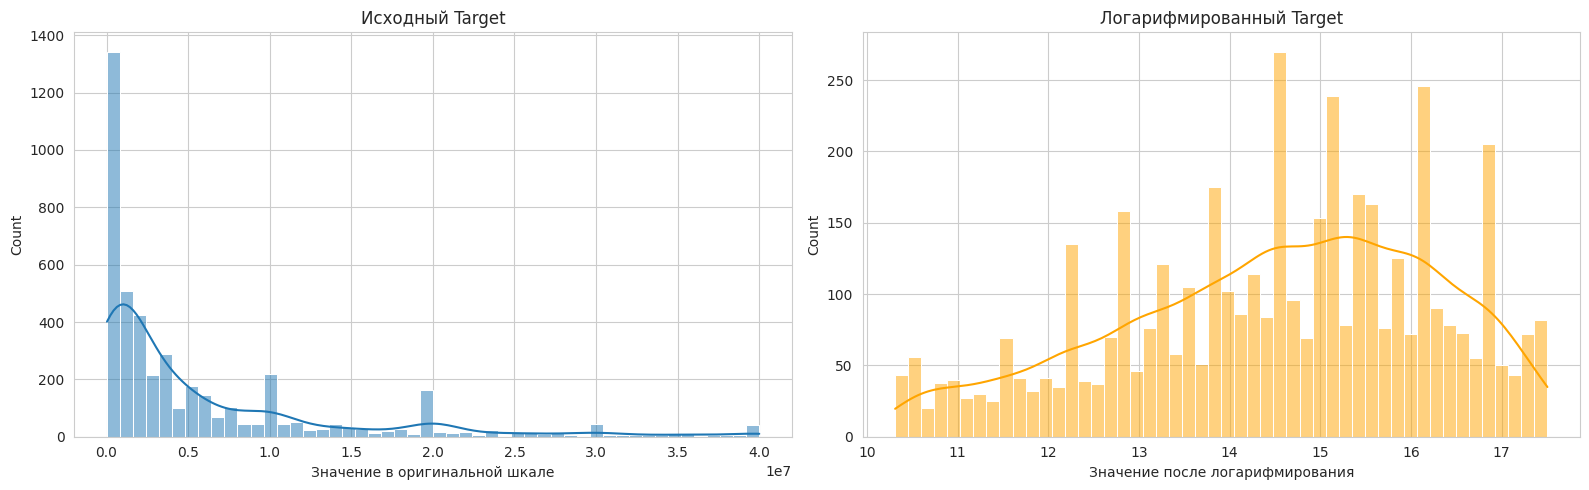

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train['target'], kde=True, ax=axes[0], bins=50)
axes[0].set_title('Исходный Target')
axes[0].set_xlabel('Значение в оригинальной шкале')

y_log = np.log1p(train['target'])
sns.histplot(y_log, kde=True, ax=axes[1], bins=50, color='orange')
axes[1].set_title('Логарифмированный Target')
axes[1].set_xlabel('Значение после логарифмирования')

plt.tight_layout()
plt.show()


Логарифмирование целевой переменной позволяет сгладить выбросы

 Поиск «пустых» и «сверх-активных» клиентов по строкам

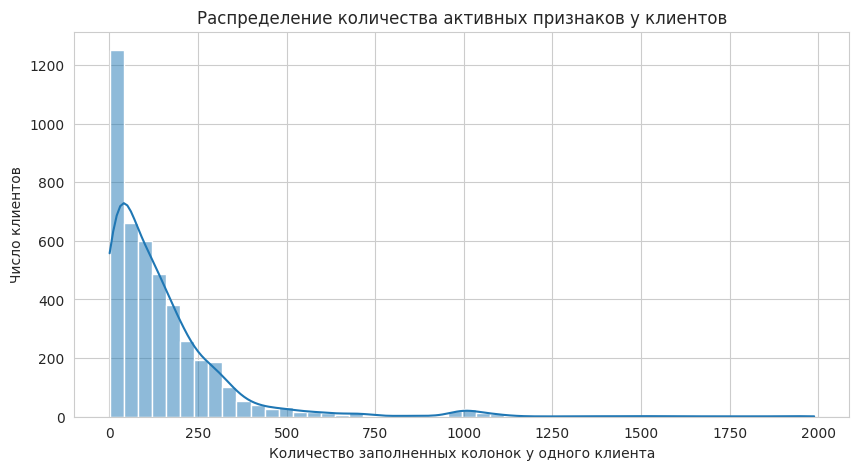

Минимум активных признаков у клиента: 1
Максимум активных признаков у клиента: 1988
Медиана активных признаков: 103.0


In [17]:
features = train.drop(columns=['ID', 'target'], errors='ignore')

non_zero_counts = (features > 0).sum(axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(non_zero_counts, bins=50, kde=True)
plt.title('Распределение количества активных признаков у клиентов')
plt.xlabel('Количество заполненных колонок у одного клиента')
plt.ylabel('Число клиентов')
plt.show()

print(f"Минимум активных признаков у клиента: {non_zero_counts.min()}")
print(f"Максимум активных признаков у клиента: {non_zero_counts.max()}")
print(f"Медиана активных признаков: {non_zero_counts.median()}")


Применим сжатие через TruncatedSVD (чтобы алгоритм не зависал на 4734 признаках) и найдём выбросы через Isolation Forest с автоматическим определением порога

In [18]:
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import IsolationForest

svd = TruncatedSVD(n_components=30, random_state=42)
X_reduced = svd.fit_transform(features)

iso_forest = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(X_reduced)

internal_scores = iso_forest.decision_function(X_reduced)

anomaly_labels = np.where(internal_scores < 0, -1, 1)

anomalies = train[anomaly_labels == -1]
normal_clients = train[anomaly_labels == 1]

print(f"Isolation Forest определил как многомерные аномалии: {len(anomalies)} строк")
print(f"Доля автоматических аномалий в датасете: {(len(anomalies) / len(train)) * 100:.2f}%")

normal_target_mean = normal_clients['target'].mean()
anomaly_target_mean = anomalies['target'].mean()

print(f"\nСредний target обычных клиентов: {normal_target_mean:,.2f}")
print(f"Средний target аномальных клиентов: {anomaly_target_mean:,.2f}")


Isolation Forest определил как многомерные аномалии: 205 строк
Доля автоматических аномалий в датасете: 4.60%

Средний target обычных клиентов: 5,624,895.78
Средний target аномальных клиентов: 12,585,885.10


# **2. Feature Engineering**

In [19]:
arr_train = X_train.values.astype(np.float32)
arr_test = test.values.astype(np.float32)

X_train['active_count'] = np.sum(arr_train > 0, axis=1)
test['active_count'] = np.sum(arr_test > 0, axis=1)

X_train['is_anomaly'] = (anomaly_labels == -1).astype(int)
test_anomaly_labels = iso_forest.predict(svd.transform(arr_test))
test['is_anomaly'] = (test_anomaly_labels == -1).astype(int)

X_train['row_sum'] = np.sum(arr_train, axis=1)
test['row_sum'] = np.sum(arr_test, axis=1)

mask_train = arr_train != 0
mask_test = arr_test != 0

with np.errstate(divide='ignore', invalid='ignore'):
    X_train['row_mean'] = np.where(X_train['active_count'] > 0, np.sum(arr_train, axis=1) / X_train['active_count'], 0)
    test['row_mean'] = np.where(test['active_count'] > 0, np.sum(arr_test, axis=1) / test['active_count'], 0)
    
    arr_train_nan = arr_train.copy()
    arr_train_nan[~mask_train] = np.nan
    arr_test_nan = arr_test.copy()
    arr_test_nan[~mask_test] = np.nan
    
    X_train['row_std'] = np.nanstd(arr_train_nan, axis=1)
    test['row_std'] = np.nanstd(arr_test_nan, axis=1)

X_train['row_std'] = X_train['row_std'].fillna(0)
test['row_std'] = test['row_std'].fillna(0)

print("\nКорреляция новых признаков с log(target):")
y_train_log = np.log1p(y_train)

new_features = ['active_count', 'is_anomaly', 'row_sum', 'row_mean', 'row_std']
for feat in new_features:
    corr = X_train[feat].corr(y_train_log)
    print(f"{feat:20} {corr:.4f}")



Корреляция новых признаков с log(target):
active_count         -0.0505
is_anomaly           0.0908
row_sum              0.2060
row_mean             0.3337
row_std              0.1255

Новые признаки успешно созданы


# 3. Обучение модели

 Используем StratifiedKFold чтобы разбить аномалии равномерно

LightGBM

In [20]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

X = X_train.copy()
y = y_train.copy()
X_test = test.copy()         

y_log = np.log1p(y)

y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'min_data_in_leaf': 20,
    'colsample_bytree': 0.25,
    'subsample': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
    
    train_data = lgb.Dataset(X_train_f, label=y_train_f)
    val_data = lgb.Dataset(X_val_f, label=y_val_f, reference=train_data)
    
    model = lgb.train(
        lgb_params,
        train_data,
        num_boost_round=2500,
        valid_sets=[train_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=150)
        ]
    )
    
    val_preds_log = model.predict(X_val_f, num_iteration=model.best_iteration)
    oof_preds[val_idx] = np.expm1(val_preds_log)
    
    test_preds_log = model.predict(X_test, num_iteration=model.best_iteration)
    test_preds += np.expm1(test_preds_log) / N_SPLITS
    
    fold_score = rmsle(y.iloc[val_idx], oof_preds[val_idx])
    print(f"Фолд {fold + 1} | Итераций: {model.best_iteration} | RMSLE: {fold_score:.4f}\n")

cv_score = rmsle(y, oof_preds)
print(f"\nLightGBM CV RMSLE: {cv_score:.4f}")

[150]	training's rmse: 1.02937	valid_1's rmse: 1.36221
Фолд 1 | Итераций: 162 | RMSLE: 1.3618

[150]	training's rmse: 1.0294	valid_1's rmse: 1.36765
[300]	training's rmse: 0.845405	valid_1's rmse: 1.35946
Фолд 2 | Итераций: 369 | RMSLE: 1.3578

[150]	training's rmse: 1.02519	valid_1's rmse: 1.37658
Фолд 3 | Итераций: 183 | RMSLE: 1.3752

[150]	training's rmse: 1.03596	valid_1's rmse: 1.35638
Фолд 4 | Итераций: 149 | RMSLE: 1.3563

[150]	training's rmse: 1.02623	valid_1's rmse: 1.4011
[300]	training's rmse: 0.841163	valid_1's rmse: 1.4
Фолд 5 | Итераций: 252 | RMSLE: 1.3978


LightGBM CV RMSLE: 1.3699


XGBoost

In [32]:
import gc
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

X = X_train.copy()
y = y_train.copy()
X_test = test.copy()
y_log = np.log1p(y)

y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_xgb = np.zeros(len(X))
test_preds_xgb = np.zeros(len(X_test))

xgb_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.25,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
    
    model = xgb.XGBRegressor(**xgb_params, n_estimators=1500, early_stopping_rounds=50)
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_train_f, y_train_f), (X_val_f, y_val_f)],
        verbose=150
    )
    
    val_preds_log = model.predict(X_val_f)
    oof_preds_xgb[val_idx] = np.expm1(val_preds_log)
    
    test_preds_log_xgb = model.predict(X_test)
    test_preds_xgb += np.expm1(test_preds_log_xgb) / N_SPLITS
    
    fold_score = rmsle(y.iloc[val_idx], oof_preds_xgb[val_idx])
    print(f"Фолд {fold + 1} | RMSLE: {fold_score:.4f}\n")
    
    del model, X_train_f, X_val_f
    gc.collect()

cv_score = rmsle(y, oof_preds_xgb)
print(f"XGBoost CV RMSLE: {cv_score:.4f}")

import os
os.makedirs('/kaggle/working/saved_models/', exist_ok=True)

np.save('/kaggle/working/saved_models/test_preds_xgb.npy', test_preds_xgb)
np.save('/kaggle/working/saved_models/oof_preds_xgb.npy', oof_preds_xgb)

submission_xgb = pd.DataFrame({
    'ID': test_ID,
    'target': test_preds_xgb
})
submission_xgb.to_csv('xgb_baseline_submission.csv', index=False)
print("Результаты XGBoost зафиксированы на диске.")

[0]	validation_0-rmse:1.74176	validation_1-rmse:1.74628
[150]	validation_0-rmse:1.08331	validation_1-rmse:1.37249
[300]	validation_0-rmse:0.95086	validation_1-rmse:1.35557
[380]	validation_0-rmse:0.90142	validation_1-rmse:1.35498
Фолд 1 | RMSLE: 1.3541

[0]	validation_0-rmse:1.74259	validation_1-rmse:1.73014
[150]	validation_0-rmse:1.07895	validation_1-rmse:1.38205
[300]	validation_0-rmse:0.94326	validation_1-rmse:1.37253
[450]	validation_0-rmse:0.84972	validation_1-rmse:1.36743
[550]	validation_0-rmse:0.79665	validation_1-rmse:1.36634
Фолд 2 | RMSLE: 1.3656

[0]	validation_0-rmse:1.74661	validation_1-rmse:1.73108
[150]	validation_0-rmse:1.08011	validation_1-rmse:1.38436
[255]	validation_0-rmse:0.97239	validation_1-rmse:1.38160
Фолд 3 | RMSLE: 1.3803

[0]	validation_0-rmse:1.73360	validation_1-rmse:1.76788
[150]	validation_0-rmse:1.09353	validation_1-rmse:1.36967
[257]	validation_0-rmse:0.97841	validation_1-rmse:1.36158
Фолд 4 | RMSLE: 1.3604

[0]	validation_0-rmse:1.74264	validation_1

CatBoost

In [22]:
from catboost import CatBoostRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

X = X_train.copy()
y = y_train.copy()
X_test = test.copy()

y_log = np.log1p(y)
y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

catboost_params = {
    'iterations': 1500,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_strength': 1,
    'bagging_temperature': 1,
    'od_type': 'Iter',
    'od_wait': 50,
    'random_seed': 42,
    'verbose': 0,
    'allow_writing_files': False,
    'task_type': 'CPU'
}


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
    
    model = CatBoostRegressor(**catboost_params)
    
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        early_stopping_rounds=50,
        verbose=150 
    )
    
    val_preds_log = model.predict(X_val_f)
    oof_preds[val_idx] = np.expm1(val_preds_log)
    
    test_preds_log = model.predict(X_test)
    test_preds += np.expm1(test_preds_log) / N_SPLITS
    
    fold_score = rmsle(y.iloc[val_idx], oof_preds[val_idx])
    print(f"Фолд {fold + 1} | Лучших итераций: {model.get_best_iteration()} | RMSLE: {fold_score:.4f}\n")

cv_score = rmsle(y, oof_preds)
print(f"\nCatBoost CV RMSLE: {cv_score:.4f}")

0:	learn: 1.7389396	test: 1.7422845	best: 1.7422845 (0)	total: 298ms	remaining: 7m 26s
150:	learn: 1.3702770	test: 1.4261868	best: 1.4261868 (150)	total: 27.9s	remaining: 4m 9s
300:	learn: 1.2989138	test: 1.3993263	best: 1.3992200 (298)	total: 55.1s	remaining: 3m 39s
450:	learn: 1.2195672	test: 1.3811077	best: 1.3809781 (446)	total: 1m 22s	remaining: 3m 11s
600:	learn: 1.1562129	test: 1.3719564	best: 1.3714185 (586)	total: 1m 49s	remaining: 2m 43s
750:	learn: 1.1061126	test: 1.3682946	best: 1.3677875 (707)	total: 2m 18s	remaining: 2m 18s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.367787506
bestIteration = 707

Shrink model to first 708 iterations.
Фолд 1 | Лучших итераций: 707 | RMSLE: 1.3678

0:	learn: 1.7408040	test: 1.7284184	best: 1.7284184 (0)	total: 257ms	remaining: 6m 25s
150:	learn: 1.3734824	test: 1.4300675	best: 1.4299849 (149)	total: 28.2s	remaining: 4m 11s
300:	learn: 1.3014726	test: 1.4062347	best: 1.4062347 (300)	total: 55.6s	remaining: 3m 41s
450

Переименум перменные в памяти и отправим на диск резултаты

In [33]:
import os
test_preds_cat = test_preds.copy()
oof_preds_cat = oof_preds.copy()


os.makedirs('/kaggle/working/saved_models/', exist_ok=True)

np.save('/kaggle/working/saved_models/test_preds_cat.npy', test_preds_cat)
np.save('/kaggle/working/saved_models/oof_preds_cat.npy', oof_preds_cat)

submission_cat = pd.DataFrame({
    'ID': test_ID,
    'target': test_preds_cat
})
submission_cat.to_csv('catboost_baseline_submission.csv', index=False)
print("Результаты CatBoost зафиксированы на диске.")


Результаты CatBoost зафиксированы на диске.


 Ridge Regression 

In [23]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import root_mean_squared_log_error

X = X_train.copy()
y = y_train.copy()
X_test = test.copy()

y_log = np.log1p(y)
y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_ridge = np.zeros(len(X))
test_preds_ridge = np.zeros(len(X_test))

max_log_target = y_log.max() 

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
     
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_f)
    X_val_scaled = scaler.transform(X_val_f)
    X_test_scaled = scaler.transform(X_test)
    
    ridge_model = Ridge(alpha=100.0, random_state=42)
    ridge_model.fit(X_train_scaled, y_train_f)
    
    val_preds_log = ridge_model.predict(X_val_scaled)
    
    val_preds_log = np.clip(val_preds_log, 0, max_log_target) 
    oof_preds_ridge[val_idx] = np.expm1(val_preds_log)
    
    test_preds_log = ridge_model.predict(X_test_scaled)
    test_preds_log = np.clip(test_preds_log, 0, max_log_target)
    test_preds_ridge += np.expm1(test_preds_log) / N_SPLITS
    
    fold_score = root_mean_squared_log_error(y.iloc[val_idx], oof_preds_ridge[val_idx])
    print(f"Фолд {fold + 1} | Валидационный RMSLE: {fold_score:.4f}\n")

cv_score_ridge = root_mean_squared_log_error(y, oof_preds_ridge)
print(f"\nRidge CV RMSLE: {cv_score_ridge:.4f}")


Фолд 1 | Валидационный RMSLE: 3.1864

Фолд 2 | Валидационный RMSLE: 3.6315

Фолд 3 | Валидационный RMSLE: 3.4460

Фолд 4 | Валидационный RMSLE: 3.4340

Фолд 5 | Валидационный RMSLE: 3.3890


Ridge CV RMSLE: 3.4204


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import root_mean_squared_log_error

X = X_train.copy()
y = y_train.copy()
X_test = test.copy()

y_log = np.log1p(y)
y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_rf = np.zeros(len(X))
test_preds_rf = np.zeros(len(X_test))

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    max_features=0.1,     
    min_samples_leaf=5,     
    n_jobs=-1,             
    random_state=42
)


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
    
    rf_model.fit(X_train_f, y_train_f)
    
    val_preds_log = rf_model.predict(X_val_f)
    oof_preds_rf[val_idx] = np.expm1(val_preds_log)
    
    test_preds_log = rf_model.predict(X_test)
    test_preds_rf += np.expm1(test_preds_log) / N_SPLITS
    
    fold_score = root_mean_squared_log_error(y.iloc[val_idx], oof_preds_rf[val_idx])
    print(f"Фолд {fold + 1} | Валидационный RMSLE: {fold_score:.4f}\n")

cv_score_rf = root_mean_squared_log_error(y, oof_preds_rf)
print(f"\nRandom Forest CV RMSLE: {cv_score_rf:.4f}")

submission_rf = pd.DataFrame({'target': test_preds_rf})
submission_rf.to_csv('rf_baseline_submission.csv', index=False)


--- Старт Stratified 5-Fold валидации на Random Forest ---
Фолд 1 | Валидационный RMSLE: 1.3946
------------------------------------------------------------
Фолд 2 | Валидационный RMSLE: 1.4175
------------------------------------------------------------
Фолд 3 | Валидационный RMSLE: 1.4057
------------------------------------------------------------
Фолд 4 | Валидационный RMSLE: 1.4012
------------------------------------------------------------
Фолд 5 | Валидационный RMSLE: 1.4176
------------------------------------------------------------

🌲 ФИНАЛЬНЫЙ CV RMSLE SCORE (Random Forest): 1.4073


# 4. Гиперпараметры optuna

In [25]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50),
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 0.6),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        
        'n_estimators': 2000,
    }
    
    X = X_train.copy()
    y = y_train.copy()
    y_log = np.log1p(y)
    y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')
    
    N_SPLITS = 3
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, val_idx in skf.split(X, y_labels):
        X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
        X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
        
        train_data = lgb.Dataset(X_train_f, label=y_train_f)
        val_data = lgb.Dataset(X_val_f, label=y_val_f, reference=train_data)
        
        model = lgb.train(
            params,
            train_data,
            valid_sets=[train_data, val_data],
            num_boost_round=2000,
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0)  # Отключаем вывод для скорости
            ]
        )
        
        val_preds_log = model.predict(X_val_f, num_iteration=model.best_iteration)
        val_preds = np.expm1(val_preds_log)
        
        fold_score = rmsle(y.iloc[val_idx], val_preds)
        fold_scores.append(fold_score)
    
    avg_score = np.mean(fold_scores)
    return avg_score

print("Запуск Optuna для подбора гиперпараметров LightGBM")

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42), 
    study_name='lgbm_optimization'
)

study.optimize(objective, n_trials=50, show_progress_bar=True)


print(f"Лучший CV RMSLE: {study.best_value:.4f}")
print("\nЛучшие параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    **study.best_params,
    'n_estimators': 2000
}

print("\nЛучшие параметры сохранены")

[I 2026-08-07 10:13:20,464] A new study created in memory with name: lgbm_optimization


Запуск Optuna для подбора гиперпараметров LightGBM
Будет выполнено 50 экспериментов (примерно 10-15 минут)...



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-07 10:13:29,951] Trial 0 finished with value: 1.3853017613152672 and parameters: {'num_leaves': 44, 'max_depth': 12, 'min_data_in_leaf': 38, 'learning_rate': 0.03968793330444373, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07, 'colsample_bytree': 0.2232334448672798, 'subsample': 0.9464704583099741}. Best is trial 0 with value: 1.3853017613152672.
[I 2026-08-07 10:13:41,244] Trial 1 finished with value: 1.3967170381983192 and parameters: {'num_leaves': 64, 'max_depth': 10, 'min_data_in_leaf': 5, 'learning_rate': 0.09330606024425668, 'reg_alpha': 0.31044435499483225, 'reg_lambda': 8.148018307012941e-07, 'colsample_bytree': 0.2727299868828402, 'subsample': 0.6733618039413735}. Best is trial 0 with value: 1.3853017613152672.
[I 2026-08-07 10:14:02,121] Trial 2 finished with value: 1.382386407212379 and parameters: {'num_leaves': 37, 'max_depth': 8, 'min_data_in_leaf': 24, 'learning_rate': 0.019553708662745254, 'reg_alpha': 0.0032112643094417484, 'reg_l

Сохраняем параметры, чтобы не обучать каждый раз

In [ ]:
import json
import joblib

with open('/kaggle/working/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print("best_params.json сохранен")

joblib.dump(study, '/kaggle/working/optuna_study.pkl')
print("optuna_study.pkl сохранен")

pd.DataFrame({
    'best_cv_rmsle': [study.best_value],
    'params': [str(study.best_params)]
}).to_csv('/kaggle/working/optuna_best_result.csv', index=False)
print("optuna_best_result.csv сохранен")

Выгружаем результаты optuna

In [ ]:
import json
import joblib

with open('/kaggle/working/best_params.json', 'r') as f:
    best_params = json.load(f)

study = joblib.load('/kaggle/working/optuna_study.pkl')

print("Optuna результаты загружены")
print(f"Лучший CV RMSLE: {study.best_value:.4f}")
print("\n   Лучшие параметры:")
for key, value in best_params.items():
    if key not in ['objective', 'metric', 'boosting_type', 'random_state', 'n_jobs', 'verbosity', 'n_estimators']:
        print(f"     {key}: {value}")

In [26]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import root_mean_squared_log_error

# 1. Готовим данные
X = X_train.copy()
y = y_train.copy()
y_log = np.log1p(y)
y_labels = pd.qcut(y_log, q=5, labels=False, duplicates='drop')

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_lgb_tuned = np.zeros(len(X))
test_preds_lgb_tuned = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):
    X_train_f, y_train_f = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y_log.iloc[val_idx]
    
    train_data = lgb.Dataset(X_train_f, label=y_train_f)
    val_data = lgb.Dataset(X_val_f, label=y_val_f, reference=train_data)
    
    model = lgb.train(
        best_params,
        train_data,
        valid_sets=[train_data, val_data],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    
    val_preds_log = model.predict(X_val_f, num_iteration=model.best_iteration)
    oof_preds_lgb_tuned[val_idx] = np.expm1(np.clip(val_preds_log, 0, None))
    
    test_preds_log = model.predict(test, num_iteration=model.best_iteration)
    test_preds_lgb_tuned += np.expm1(np.clip(test_preds_log, 0, None)) / N_SPLITS
    
    fold_score = root_mean_squared_log_error(y.iloc[val_idx], oof_preds_lgb_tuned[val_idx])
    print(f"Фолд {fold + 1} | Итераций: {model.best_iteration} | RMSLE: {fold_score:.4f}")

final_cv_lgb = root_mean_squared_log_error(y, oof_preds_lgb_tuned)
print(f"\nСкор улучшенного LightGBM: {final_cv_lgb:.4f}")


--- Старт ФИНАЛЬНОГО ОБУЧЕНИЯ LightGBM на параметрах Optuna (5 Фолд) ---
Фолд 1 | Итераций: 488 | Честный RMSLE: 1.3441
Фолд 2 | Итераций: 534 | Честный RMSLE: 1.3613
Фолд 3 | Итераций: 284 | Честный RMSLE: 1.3754
Фолд 4 | Итераций: 405 | Честный RMSLE: 1.3529
Фолд 5 | Итераций: 297 | Честный RMSLE: 1.3933

ИТОГОВЫЙ СКОР УЛУЧШЕННОГО LightGBM НА 5 ФОЛДАХ: 1.3655


# 5. Ансамбль

In [34]:
weight_lgb_tuned = 0.40 
weight_xgb       = 0.35  
weight_cat       = 0.15  
weight_rf        = 0.10  

assert np.isclose(weight_lgb_tuned + weight_xgb + weight_cat + weight_rf, 1.0), "Ошибка: сумма весов должна быть равна 1.0!"

final_ensemble_preds = (
    weight_lgb_tuned * test_preds_lgb_tuned + 
    weight_xgb       * test_preds_xgb +   
    weight_cat       * test_preds_cat +      
    weight_rf        * test_preds_rf    
)

final_ensemble_preds = np.clip(final_ensemble_preds, 0, None)

submission_final = pd.DataFrame({
    'ID': test_ID,
    'target': final_ensemble_preds
})

submission_final.to_csv('final_submission.csv', index=False)

print(f"Пропорция бленда: Optuna-LGBM ({weight_lgb_tuned}) + XGBoost ({weight_xgb}) + CatBoost ({weight_cat}) + RF ({weight_rf})")
print("Файл 'final_submission.csv' успешно создан")

print("\nСтатистика финальных ответов:")
print(submission_final['target'].describe())

Пропорция бленда: Optuna-LGBM (0.4) + XGBoost (0.35) + CatBoost (0.15) + RF (0.1)
Файл 'final_submission.csv' успешно создан

Статистика финальных ответов:
count    4.934200e+04
mean     3.348021e+06
std      2.011468e+06
min      8.926400e+04
25%      2.170781e+06
50%      3.048581e+06
75%      4.232416e+06
max      3.256484e+07
Name: target, dtype: float64
